# Lab 1

## Estimating worst-case/average-case complexity of algorithms via linear and binary search.

### 1. Linear Search

In [1]:
import math
import random

import matplotlib.pyplot as plt
from matplotlib.pyplot import figure

import pandas as pd
import csv
csv.field_size_limit(10**10)  # Increase CSV field size limit to handle large data

131072

In [2]:
MAX_RAND_LIMIT = 0
ITER_CTR = 0 # no. of iterations

In [3]:
def linearSearch(arr, q):
    # global n
    global ITER_CTR
    for i in range(len(arr)):
        ITER_CTR += 1
        if (arr[i] == q):
            return i

In [4]:
def testLinearSearch(num, maxRandLimit):
    # `num`          -> size of the slice to take from the master array this run
    # `maxRandLimit` -> hard ceiling: no random integer anywhere in the program may exceed this
    global ITER_CTR
    start = random.randint(0, len(master_data) - num)   # bounded so start + num never overruns the array
    arr = master_data[start:start + num]
    assert all(x <= maxRandLimit for x in arr), "generated random number exceeds hard limit"

    first_q = arr[0]
    middle_q = arr[len(arr) // 2]
    last_q = arr[-1]

    ITER_CTR = 0
    linearSearch(arr, first_q)
    n_first = ITER_CTR

    ITER_CTR = 0
    linearSearch(arr, middle_q)
    n_middle = ITER_CTR

    ITER_CTR = 0
    linearSearch(arr, last_q)
    n_last = ITER_CTR

    return (n_first, n_middle, n_last), (arr, (first_q, middle_q, last_q))

def data_builder(n, maxRandLimit):
    # Builds ONE sorted list of `n` unique random elements, every one <= maxRandLimit.
    # This dedup loop is the one intentionally "convoluted" part of the program.
    elements = set()
    while len(elements) < n:
        elements.add(random.randint(0, maxRandLimit))
    return sorted(elements)

def test_size_list(max_size):
    # Produces the sweep of array sizes to test -- a role data_builder used to play
    # before it was repurposed to build the master array. Every size from 1 to
    # max_size is considered now, no sampling.
    return list(range(1, max_size + 1))

def run_n_times(iterations, sample_size):
    global master_data
    max_array_size = 10 ** sample_size          # RUN_SIZE indirectly caps the array size
    master_data = data_builder(max_array_size, MAX_RAND_LIMIT)
    test_sizes = test_size_list(len(master_data))

    results_best = [[] for i in range(len(test_sizes))]
    results_avg = [[] for i in range(len(test_sizes))]
    results_worst = [[] for i in range(len(test_sizes))]
    arr_queries_datastore = []

    for i in range(iterations):
        for j in range(len(test_sizes)):
            (n_first, n_middle, n_last), (arr, queries) = testLinearSearch(test_sizes[j], MAX_RAND_LIMIT)
            results_best[j].append(n_first)
            results_avg[j].append(n_middle)
            results_worst[j].append(n_last)
            arr_queries_datastore.append((arr, queries, (n_first, n_middle, n_last)))

    for j in range(len(test_sizes)):
        results_best[j] = min(results_best[j])
        results_avg[j] = sum(results_avg[j]) // iterations
        results_worst[j] = max(results_worst[j])

    return (test_sizes, (results_best, results_avg, results_worst), arr_queries_datastore)

In [5]:
ITER_RUNS = 4
RUN_SIZE = 3                               # max array size = 10 ** RUN_SIZE
MAX_RAND_LIMIT = (10 ** RUN_SIZE) * 10     # hard ceiling on every generated random integer

test_sizes, (results_best, results_avg, results_worst), arr_queries_datastore = run_n_times(ITER_RUNS, RUN_SIZE)

In [6]:
for i in range(len(arr_queries_datastore)):
    row = arr_queries_datastore[i]
    row_modifiable = list(row)
    row_modifiable.append(len(row_modifiable[0]))
    row_modifiable[0] = str(row_modifiable[0]).replace(',', ' ') # Enhance CSV Compatibility
    row = tuple(row_modifiable)
    arr_queries_datastore[i] = row

In [7]:
results_dataset = pd.DataFrame(arr_queries_datastore, columns=['Array', 'Queries (first, middle, last)', 'Comparisons (first, middle, last)', 'Data Size'])

In [8]:
results_dataset

,Array,"Queries (first, middle, last)","Comparisons (first, middle, last)",Data Size
0,[3784],"(3784, 3784, 3784)","(1, 1, 1)",1
1,[1496 1502],"(1496, 1502, 1502)","(1, 2, 2)",2
2,[1178 1190 1203],"(1178, 1190, 1203)","(1, 2, 3)",3
3,[1457 1462 1467 1471],"(1457, 1467, 1471)","(1, 3, 4)",4
4,[1908 1910 1912 1913 1916],"(1908, 1912, 1916)","(1, 3, 5)",5
...,...,...,...,...
3995,[38 43 47 70 78 91 94 101 114 128 13...,"(38, 5033, 9963)","(1, 499, 996)",996
3996,[19 38 43 47 70 78 91 94 101 114 128...,"(19, 5021, 9963)","(1, 499, 997)",997
3997,[38 43 47 70 78 91 94 101 114 128 13...,"(38, 5051, 9994)","(1, 500, 998)",998
3998,[38 43 47 70 78 91 94 101 114 128 13...,"(38, 5051, 9996)","(1, 500, 999)",999


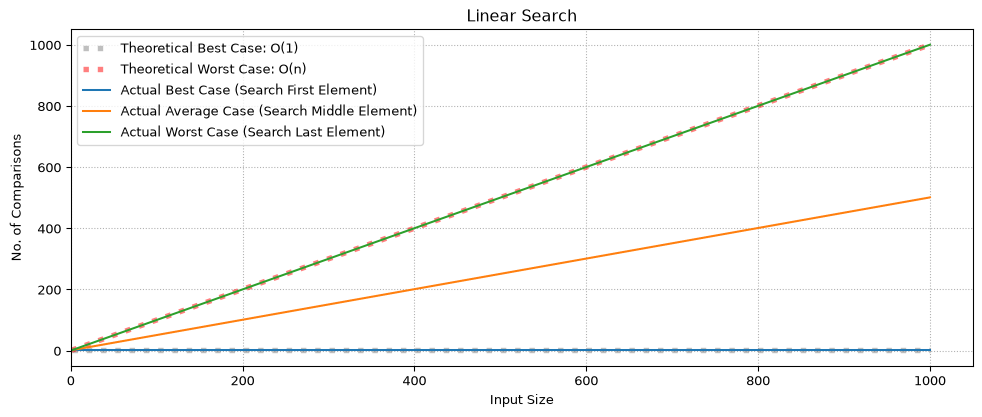

In [12]:
figure(figsize=(12, 4.5), dpi=97)

x = test_sizes[:]
y1 = [1 for i in test_sizes[:]] # theoretical best case
y2 = results_avg[:] # actual average case (middle element)
y3 = [i for i in test_sizes[:]] # theoretical worst case

plt.plot(x, y1, linestyle=':', color='gray', alpha=0.5, label="Theoretical Best Case: O(1)", linewidth=4)
plt.plot(x, y3, linestyle=':', color='red', alpha=0.5, label="Theoretical Worst Case: O(n)", linewidth=4)

plt.plot(x, results_best, label="Actual Best Case (Search First Element)")
plt.plot(x, y2, label="Actual Average Case (Search Middle Element)")
plt.plot(x, results_worst, label="Actual Worst Case (Search Last Element)")

plt.xlim(left=0)

plt.legend()
plt.xlabel("Input Size")
plt.ylabel("No. of Comparisons")
plt.title("Linear Search")
plt.grid(visible=True, linestyle=':')
plt.show()

### 2. Binary Search

In [10]:
ITER_CTR = 0
MAX_RAND_LIMIT_B = 0

In [11]:
def binarySearch(arr, q, low, high):
    global ITER_CTR
    if (low > high) or ((low == high) and (q != low)) or (high >= len(arr)):
        return None
    mid = int((high - low)//2) + low
    if arr[mid] == q:
        ITER_CTR += 1 # type: ignore
        return mid
    if q < arr[mid]:
        ITER_CTR += 1 # type: ignore
        return binarySearch(arr, q, low, mid-1)
    if q > arr[mid]:
        ITER_CTR += 1 # type: ignore
        return binarySearch(arr, q, mid+1, high)
    return None

In [12]:
def testBinarySearch(num, maxRandLimit):
    # `num`          -> size of the slice to take from the master array this run
    # `maxRandLimit` -> hard ceiling: no random integer anywhere in the program may exceed this
    global ITER_CTR
    start = random.randint(0, len(master_data) - num)   # bounded so start + num never overruns the array
    arr = master_data[start:start + num]
    assert all(x <= maxRandLimit for x in arr), "generated random number exceeds hard limit"

    first_q = arr[len(arr) // 2]
    middle_q = arr[(len(arr) // 2) if random.randint(0, 1) == 0 else -1]
    last_q = arr[-1]

    ITER_CTR = 0
    binarySearch(arr, first_q, 0, num-1)
    n_first = ITER_CTR

    ITER_CTR = 0
    binarySearch(arr, middle_q, 0, num-1)
    n_middle = ITER_CTR

    ITER_CTR = 0
    binarySearch(arr, last_q, 0, num-1)
    n_last = ITER_CTR

    return (n_first, n_middle, n_last), (arr, (first_q, middle_q, last_q))

def data_builder(n, maxRandLimit):
    # Builds ONE sorted list of `n` unique random elements, every one <= maxRandLimit.
    # This dedup loop is the one intentionally "convoluted" part of the program.
    elements = set()
    while len(elements) < n:
        elements.add(random.randint(0, maxRandLimit))
    return sorted(elements)

def test_size_list(max_size):
    # Every size from 1 to max_size is considered, no sampling.
    return list(range(1, max_size + 1))

def run_n_times_binary(iterations, sample_size):
    global master_data
    max_array_size = 10 ** sample_size          # RUN_SIZE_B indirectly caps the array size
    master_data = data_builder(max_array_size, MAX_RAND_LIMIT_B)
    test_sizes = test_size_list(len(master_data))

    results_best_b = [[] for i in range(len(test_sizes))]
    results_avg_b = [[] for i in range(len(test_sizes))]
    results_worst_b = [[] for i in range(len(test_sizes))]
    arr_queries_datastore_b = []

    for i in range(iterations):
        for j in range(len(test_sizes)):
            (n_first, n_middle, n_last), (arr, queries) = testBinarySearch(test_sizes[j], MAX_RAND_LIMIT_B)
            results_best_b[j].append(n_first)
            results_avg_b[j].append(n_middle)
            results_worst_b[j].append(n_last)
            arr_queries_datastore_b.append((arr, queries, (n_first, n_middle, n_last)))

    for j in range(len(test_sizes)):
        results_best_b[j] = min(results_best_b[j])
        results_avg_b[j] = sum(results_avg_b[j]) // iterations
        results_worst_b[j] = max(results_worst_b[j])

    return (test_sizes, (results_best_b, results_avg_b, results_worst_b), arr_queries_datastore_b)

In [13]:
ITER_RUNS_B = 4
RUN_SIZE_B = 3                                 # max array size = 10 ** RUN_SIZE_B
MAX_RAND_LIMIT_B = (10 ** RUN_SIZE_B) * 10     # hard ceiling on every generated random integer

test_sizes, (results_best_b, results_avg_b, results_worst_b), arr_queries_datastore_b = run_n_times_binary(ITER_RUNS_B, RUN_SIZE_B)

In [14]:
for i in range(len(arr_queries_datastore_b)):
    row = arr_queries_datastore_b[i]
    row_modifiable = list(row)
    row_modifiable.append(len(row_modifiable[0]))
    row_modifiable[0] = str(row_modifiable[0]).replace(',', ' ') # Enhance CSV Compatibility
    row = tuple(row_modifiable)
    arr_queries_datastore_b[i] = row

In [15]:
results_dataset_b = pd.DataFrame(arr_queries_datastore_b, columns=['Array', 'Queries (first, middle, last)', 'Comparisons (first, middle, last)', 'Data Size'])

In [16]:
results_dataset_b

,Array,"Queries (first, middle, last)","Comparisons (first, middle, last)",Data Size
0,[9049],"(9049, 9049, 9049)","(0, 0, 0)",1
1,[6636 6640],"(6640, 6640, 6640)","(1, 1, 1)",2
2,[9793 9798 9814],"(9798, 9814, 9814)","(1, 1, 1)",3
3,[1016 1026 1042 1062],"(1042, 1062, 1062)","(2, 2, 2)",4
4,[1685 1698 1716 1718 1727],"(1716, 1716, 1727)","(1, 1, 2)",5
...,...,...,...,...
3995,[35 40 47 52 66 70 81 84 113 120 152...,"(4989, 4989, 9969)","(9, 9, 9)",996
3996,[20 24 34 35 40 47 52 66 70 81 84 1...,"(4969, 4969, 9961)","(1, 1, 9)",997
3997,[34 35 40 47 52 66 70 81 84 113 120 ...,"(4989, 4989, 9982)","(9, 9, 9)",998
3998,[20 24 34 35 40 47 52 66 70 81 84 1...,"(4985, 4985, 9969)","(1, 1, 9)",999


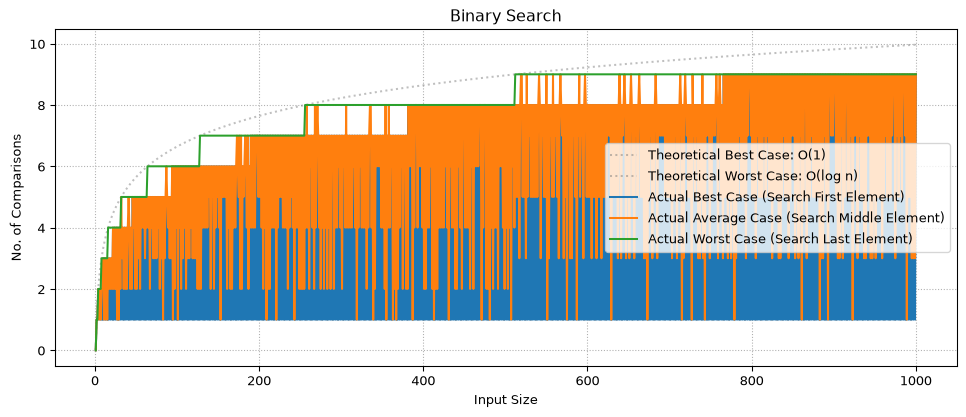

In [17]:
figure(figsize=(12, 4.5), dpi=97)

x = test_sizes[:]
y1 = [1 for i in test_sizes[:]]                 # theoretical best case
y2 = results_avg_b[:]                           # actual average case (middle element)
y3 = [math.log2(i) for i in test_sizes[:]]      # theoretical worst case

plt.plot(x, y1, linestyle=':', color='gray', alpha=0.5, label="Theoretical Best Case: O(1)")
plt.plot(x, y3, linestyle=':', color='gray', alpha=0.5, label="Theoretical Worst Case: O(log n)")

plt.plot(x, results_best_b, label="Actual Best Case (Search First Element)")
plt.plot(x, y2, label="Actual Average Case (Search Middle Element)")
plt.plot(x, results_worst_b, label="Actual Worst Case (Search Last Element)")

plt.legend()
plt.xlabel("Input Size")
plt.ylabel("No. of Comparisons")
plt.title("Binary Search")
plt.grid(visible=True, linestyle=':')
plt.show()

### 3. Comparison b/w Linear and Binary Search Algorithms

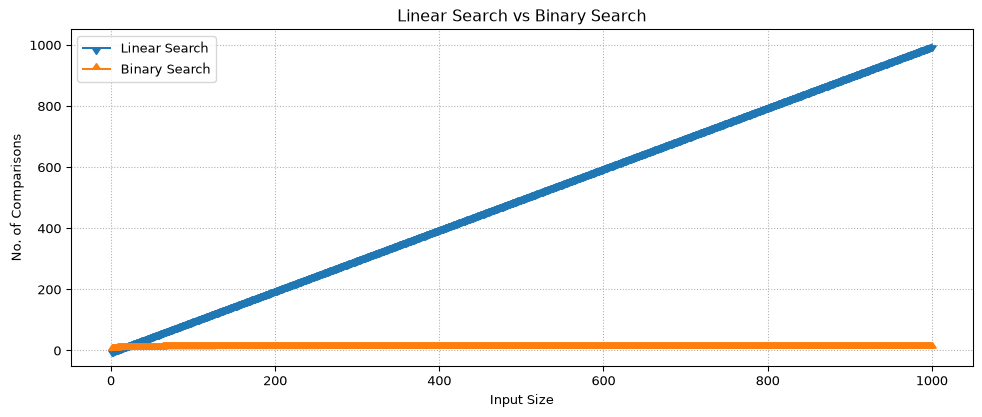

In [18]:
figure(figsize=(12, 4.5), dpi=97)

x = test_sizes[:]
y1 = results_worst[:] # Linear Search
y2 = results_worst_b[:] # Binary Search

plt.plot(x, y1, label="Linear Search", marker=11)
plt.plot(x, y2, label="Binary Search", marker=10)

plt.legend()
plt.xlabel("Input Size")
plt.ylabel("No. of Comparisons")
plt.title("Linear Search vs Binary Search")
plt.grid(visible=True, linestyle=':')
plt.show()

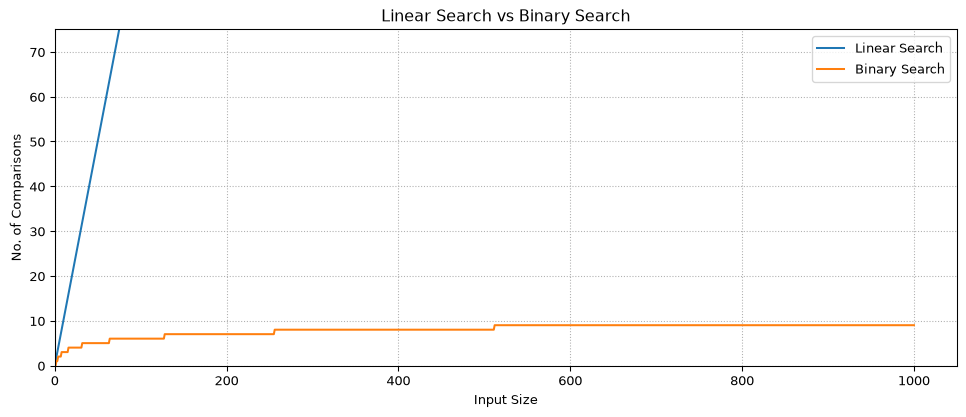

In [19]:
figure(figsize=(12, 4.5), dpi=97)

x = test_sizes[:]
y1 = results_worst[:] # Linear Search
y2 = results_worst_b[:] # Binary Search

plt.plot(x, y1, label="Linear Search")
plt.plot(x, y2, label="Binary Search")

plt.ylim(top=75, bottom=0)
plt.xlim(left=0)

plt.legend()
plt.xlabel("Input Size")
plt.ylabel("No. of Comparisons")
plt.title("Linear Search vs Binary Search")
plt.grid(visible=True, linestyle=':')
plt.show()

# Save the Datasets and Search Results

In [20]:
results_dataset.to_csv('2650026_lab1_data0_latest.csv', index=False, lineterminator='\n')
results_dataset_b.to_csv('2650026_lab1_data1_latest.csv', index=False, lineterminator='\n')

In [21]:
summarised_results_df = pd.DataFrame([test_sizes, results_worst, results_worst_b], index=['Input Size', 'Iterations (Worst Case) - Linear Search, '+str(ITER_RUNS)+' runs)', 'Iterations (Worst Case) - Binary Search, '+str(ITER_RUNS_B)+' runs)']).transpose()
summarised_results_df.to_csv('2650026_lab1_summary_latest.csv', index=False, lineterminator='\n')